# XSpect pipeline, step by step — Fe Kα/Kβ static XES (mfx100895324)

**Goal of this notebook:** open up the `mfx100895324_static_xes.yaml` pipeline
and run *each step by hand* on a single run so you can watch the data change at
every stage. Nothing here is hidden inside `Pipeline.run()` — we call the exact
same registered step functions the pipeline calls, one at a time, and plot the
`run` object before and after.

We use **run 36** (Fe(III) ferricyanide, the oxidized reference) as the example.

### The experiment in one paragraph
Two iron emission lines — **Fe Kα** (~6400 eV) and **Fe Kβ** (~7058 eV) — are
dispersed by two bent-crystal analyzers onto **one** ePix100 detector. Each
X-ray shot gives a `(300 rows × 710 cols)` image where **columns = energy
(dispersion)** and **rows = position (cross-dispersion)**. The two emission
lines land in two different bands of rows. Our job: turn ~29,000 noisy 2D shot
images into two clean 1D emission spectra on a calibrated energy axis.

### The 7 pipeline steps (from the YAML)
| # | Step | What it does |
|---|------|-------------|
| 1 | `union_shots` | keep only X-ray-on shots |
| 2 | `filter_detector_adu` | zero pixels below 3 ADU (noise floor) |
| 3 | `reduce_detector_shots` | sum all shots → one 2D image |
| 4 | `patch_pixels` | repair hot pixels / ASIC-gap columns |
| 5 | `reduce_detector_spatial` | two row-ROIs (Kα, Kβ) → two 1D spectra |
| 6 | `make_energy_axis` (Kα) | pixel → eV via LiNbO₃ crystal geometry |
| 7 | `make_energy_axis` (Kβ) | pixel → eV via Ge crystal geometry |

Each step is a plain function `step(run, **kwargs)` that reads attributes off
the `run` object and writes new ones back. That's the whole contract.

## 0. Setup — imports and the run object

We add the XSpect repo root to `sys.path` (same trick as the visualization
notebook) so `from XSpect import ...` works without installing the package.

Then we build ONE `spectroscopy_run` for run 36 by hand — this is exactly what
`Pipeline.run()` does internally per run. We load:
- the **scalar keys** (`xray`, `laser`, `ipm`) immediately, and
- the **detector** (`epix100_1/ROI_area`) as a big `(nshots, 300, 710)` array.

> **Note on memory / speed:** the full run is ~29k shots × 300 × 710 float64
> ≈ 49 GB if loaded whole. For teaching we cap it with `MAX_SHOTS` so it loads
> in seconds and fits in RAM. The *shape of every operation* is identical to the
> full run — only the shot count changes. Bump `MAX_SHOTS` (or set it to `None`)
> if you have the memory and want the real summed statistics.

In [1]:
import os, sys

HERE = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT = os.path.abspath(os.path.join(HERE, '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as plt

# The model objects and the registered step functions — the SAME functions the
# YAML pipeline dispatches. We import them directly so we can call them one at a
# time and inspect the run object in between.
from XSpect.model.experiment import spectroscopy_experiment
from XSpect.model.run import spectroscopy_run
from XSpect.analysis.spectroscopy import (
    union_shots,
    filter_detector_adu,
    reduce_detector_shots,
    reduce_detector_spatial,
)
from XSpect.analysis.xes import patch_pixels, make_energy_axis

RUN_NUMBER = 36          # Fe(III) ferricyanide, the oxidized reference
MAX_SHOTS  = 4000        # cap shots for a fast, low-memory teaching run
                         # (set to None to load the entire run)

print('repo root :', REPO_ROOT)
print('run       :', RUN_NUMBER)
print('max shots :', MAX_SHOTS)

repo root : /sdf/data/lcls/ds/mfx/mfx100895324/results/lbgee/XSpect
run       : 36
max shots : 4000


In [2]:
# Build the experiment + run objects. This mirrors Pipeline._create_run().
exp = spectroscopy_experiment(1, 'mfx', 'mfx100895324')
print('experiment directory:', exp.experiment_directory)

end_index = MAX_SHOTS if MAX_SHOTS is not None else -1
run = spectroscopy_run(exp, RUN_NUMBER, end_index=end_index)
run.verbose = True   # print each step's status line as it runs
print('run file:', run.run_file)

experiment directory: /sdf/data/lcls/ds/mfx/mfx100895324/hdf5/smalldata
run file: /sdf/data/lcls/ds/mfx/mfx100895324/hdf5/smalldata/mfx100895324_Run0036.h5


In [3]:
# Load scalar keys (fast) and the shot masks (xray/laser/simultaneous).
# These friendly names come straight from the YAML `data.keys` mapping:
#   lightStatus/xray  -> xray
#   lightStatus/laser -> laser
#   MfxDg2BmMon/totalIntensityJoules -> ipm
run.load_run_keys(
    ['lightStatus/xray', 'lightStatus/laser', 'MfxDg2BmMon/totalIntensityJoules'],
    ['xray', 'laser', 'ipm'],
)
run.get_run_shot_properties()   # sets run.xray, run.laser, run.simultaneous, run.total_shots

print('total shots loaded :', run.total_shots)
print('xray-on shots      :', int(np.sum(run.xray)))
print('laser-on shots     :', int(np.sum(run.laser)),
      '  <-- static experiment, expect 0')

HDF5 import of keys completed. Time: 0.02 seconds
Obtained shot properties
total shots loaded : 4000
xray-on shots      : 4000
laser-on shots     : 0   <-- static experiment, expect 0


In [4]:
# Load the detector as `epix` — matches YAML detector_keys (name: epix).
# Shape is (nshots, 300 rows, 710 cols). This is the big array.
run.load_run_key_delayed(['epix100_1/ROI_area'], ['epix'])
if hasattr(run, 'h5'):
    run.h5.close(); del run.h5   # close file handle (Pipeline does this too)

print('run.epix shape :', run.epix.shape, run.epix.dtype)
print('memory         : %.2f GB' % (run.epix.nbytes / 1e9))

HDF5 import of keys completed. Time: 1.41 seconds
run.epix shape : (4000, 300, 710) float64
memory         : 6.82 GB


### First look — a single raw shot vs. the raw sum

Before any processing: one shot is almost pure noise (a few photons scattered
across the chip). The signal only emerges when you sum many shots. The two
horizontal bands are the two emission lines.

The dashed boxes show the two row-ROIs we'll extract in step 5:
**Kα = rows 228–248**, **Kβ = rows 158–180**.

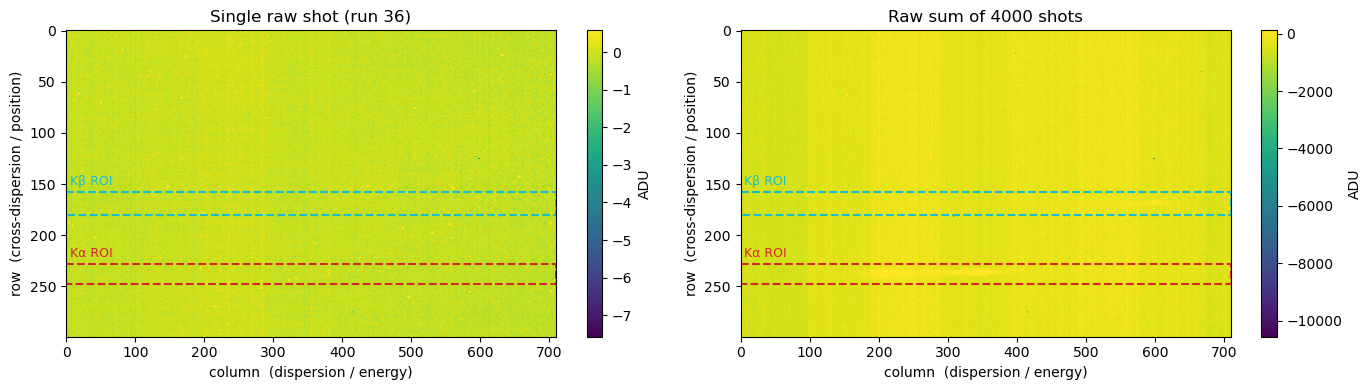

In [5]:
def add_roi_boxes(ax):
    # (col_start, row_start), width, height — full column span, ROI row span
    for (r0, r1), label, color in [((228, 248), 'Kα ROI', 'tab:red'),
                                   ((158, 180), 'Kβ ROI', 'tab:cyan')]:
        ax.add_patch(plt.Rectangle((0, r0), 710, r1 - r0, fill=False,
                                   edgecolor=color, lw=1.5, ls='--'))
        ax.text(5, r0 - 4, label, color=color, fontsize=9, va='bottom')

raw_sum = run.epix.sum(axis=0)          # sum over the loaded shots -> (300, 710)
single  = run.epix[np.argmax(run.xray)] # one x-ray-on shot

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im0 = axes[0].imshow(single, aspect='auto', cmap='viridis',
                     vmax=np.percentile(single, 99.9))
axes[0].set_title(f'Single raw shot (run {RUN_NUMBER})')
add_roi_boxes(axes[0]); fig.colorbar(im0, ax=axes[0], label='ADU')

im1 = axes[1].imshow(raw_sum, aspect='auto', cmap='viridis',
                     vmax=np.percentile(raw_sum, 99.5))
axes[1].set_title(f'Raw sum of {run.epix.shape[0]} shots')
add_roi_boxes(axes[1]); fig.colorbar(im1, ax=axes[1], label='ADU')
for ax in axes:
    ax.set_xlabel('column  (dispersion / energy)')
    ax.set_ylabel('row  (cross-dispersion / position)')
plt.tight_layout(); plt.show()

## Step 1 — `union_shots`: keep only X-ray-on shots

**YAML:**
```yaml
- step: union_shots
  on: epix
  filter_keys: [xray, xray]
  new_key: epix
```

`union_shots` builds a boolean mask by AND-ing together every mask named in
`filter_keys`, then keeps only those shots of the array named by `on`. Here both
entries are `xray`, so `xray AND xray = xray` — a simple "drop the X-ray-off
shots" filter. Writing back to `new_key: epix` overwrites the array in place.

Watch the **first dimension (shot count) shrink** while rows/cols stay `300×710`.

In [6]:
shots_before = run.epix.shape[0]

union_shots(run, on='epix', filter_keys=['xray', 'xray'], new_key='epix')

shots_after = run.epix.shape[0]
print(f'shots: {shots_before} -> {shots_after} '
      f'({shots_before - shots_after} X-ray-off shots removed)')
print('epix shape now:', run.epix.shape)

Union shots: epix with masks ['xray', 'xray'] -> epix (4000 shots)
shots: 4000 -> 4000 (0 X-ray-off shots removed)
epix shape now: (4000, 300, 710)


## Step 2 — `filter_detector_adu`: zero the noise floor

**YAML:**
```yaml
- step: filter_detector_adu
  on: epix
  adu_threshold: 3.0
```

Every pixel below **3.0 ADU** is set to zero (`img * (img > 3.0)`). This kills
low-level electronic read noise that would otherwise accumulate into a large
spurious baseline when we sum thousands of shots. Real photon hits are well
above 3 ADU and survive untouched.

Below: the per-pixel value distribution before/after (log-y). Everything left of
the dashed line at 3 ADU gets clamped to exactly zero.

ADU filtered epix with threshold 3.0


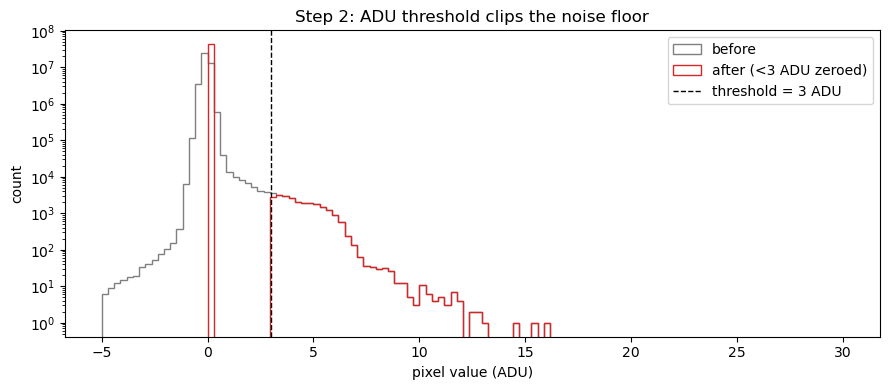

fraction of pixels now exactly zero (sampled): 0.999


In [7]:
sample = run.epix[:200].ravel()   # a subset of pixels, pre-filter, for the histogram

filter_detector_adu(run, on='epix', adu_threshold=3.0)

sample_after = run.epix[:200].ravel()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(-5, 30, 120)
ax.hist(sample, bins=bins, histtype='step', label='before', color='tab:gray')
ax.hist(sample_after, bins=bins, histtype='step', label='after (<3 ADU zeroed)',
        color='tab:red')
ax.axvline(3.0, ls='--', color='k', lw=1, label='threshold = 3 ADU')
ax.set_yscale('log'); ax.set_xlabel('pixel value (ADU)'); ax.set_ylabel('count')
ax.set_title('Step 2: ADU threshold clips the noise floor')
ax.legend(); plt.tight_layout(); plt.show()

frac_zero = np.mean(run.epix[:200] == 0)
print(f'fraction of pixels now exactly zero (sampled): {frac_zero:.3f}')

## Step 3 — `reduce_detector_shots`: sum over all shots

**YAML:**
```yaml
- step: reduce_detector_shots
  on: epix
  reduction: sum
  purge: true
```

Collapse the shot dimension with `np.nansum(..., axis=0)`: the `(nshots, 300,
710)` stack becomes a single `(300, 710)` image. The result is written to a
**new** attribute `epix_reduced`, and because `purge: true`, the giant per-shot
array `epix` is dropped (set to `None`) to free memory.

This is the "static" heart of the analysis — no time or laser dimension, just
one integrated image per run.

Shot reduction: epix -> epix_reduced
epix (per-shot) after purge : None
epix_reduced shape          : (300, 710)


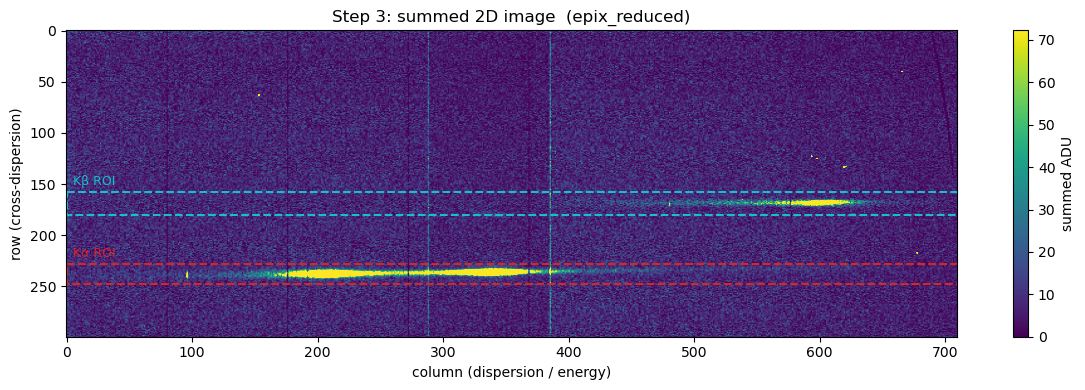

In [8]:
reduce_detector_shots(run, on='epix', reduction='sum', purge=True)

print('epix (per-shot) after purge :', run.epix)          # -> None
print('epix_reduced shape          :', run.epix_reduced.shape)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(run.epix_reduced, aspect='auto', cmap='viridis',
               vmax=np.percentile(run.epix_reduced, 99.5))
add_roi_boxes(ax)
ax.set_title('Step 3: summed 2D image  (epix_reduced)')
ax.set_xlabel('column (dispersion / energy)')
ax.set_ylabel('row (cross-dispersion)')
fig.colorbar(im, ax=ax, label='summed ADU')
plt.tight_layout(); plt.show()

## Step 4 — `patch_pixels`: repair hot pixels & ASIC-gap columns

**YAML:**
```yaml
- step: patch_pixels
  on: epix_reduced
  auto_detect: true
  mode: polynomial
  axis: 1
  threshold: 5.0
  nsigma: 6.0
  max_gap_width: 3
  smooth_window: 21
```

The ePix100 is built from ASIC tiles; at their boundaries you get **dead/gap
columns** (artificially low) and **charge-sharing spikes** (artificially high).
Left alone these are sharp vertical stripes that corrupt the spectrum.

With `auto_detect: true`, the step:
1. builds a **column profile** (sum over rows) of the image,
2. compares it to a median-filtered **baseline** (`smooth_window=21`),
3. flags columns by both a **global ratio** test (`threshold=5.0`) and a
   **robust z-score** test (`nsigma=6.0`) keeping only narrow clusters
   (`max_gap_width=3`),
4. **polynomial-patches** each flagged column (`axis=1` = columns) by fitting a
   line to clean neighbors and evaluating at the bad column.

Handy: the step stores its diagnostics right on the run object
(`epix_reduced_col_profile`, `_col_baseline`, `_col_zscore`,
`_auto_patched_pixels`) so we can see exactly which columns it chose and why.

In [9]:
before_patch = run.epix_reduced.copy()   # keep a copy to compare

patch_pixels(
    run, on='epix_reduced', auto_detect=True, mode='polynomial', axis=1,
    threshold=5.0, nsigma=6.0, max_gap_width=3, smooth_window=21,
)

auto = run.epix_reduced_auto_patched_pixels
print(f'auto-detected {len(auto)} bad columns:')
print('  spikes :', run.epix_reduced_auto_spike_cols)
print('  dead   :', run.epix_reduced_auto_dead_cols)

patch_pixels auto_detect: 7 spikes + 7 dead = 14 auto + 0 manual = 14 total on epix_reduced (threshold=5.0, nsigma=6.0, max_gap_width=3)
Patched 14 pixels on epix_reduced (axis=1, mode=polynomial)
auto-detected 14 bad columns:
  spikes : [153, 288, 363, 385, 619, 665, 677]
  dead   : [80, 176, 192, 272, 362, 368, 708]


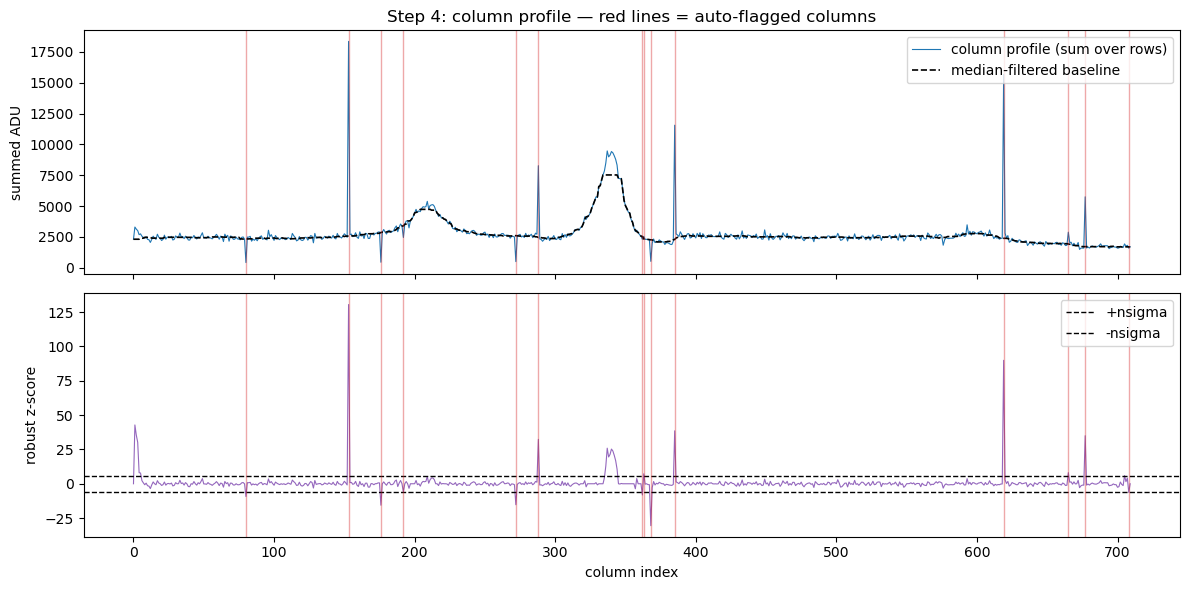

In [10]:
# Visualize WHY those columns were flagged: profile vs baseline, and z-score.
prof = run.epix_reduced_col_profile
base = run.epix_reduced_col_baseline
z    = run.epix_reduced_col_zscore

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(prof, color='tab:blue', lw=0.8, label='column profile (sum over rows)')
axes[0].plot(base, color='k', lw=1.2, ls='--', label='median-filtered baseline')
for c in auto:
    axes[0].axvline(c, color='tab:red', alpha=0.4, lw=1)
axes[0].set_ylabel('summed ADU'); axes[0].legend(loc='upper right')
axes[0].set_title('Step 4: column profile — red lines = auto-flagged columns')

axes[1].plot(z, color='tab:purple', lw=0.8)
axes[1].axhline( 6.0, ls='--', color='k', lw=1, label='+nsigma')
axes[1].axhline(-6.0, ls='--', color='k', lw=1, label='-nsigma')
for c in auto:
    axes[1].axvline(c, color='tab:red', alpha=0.4, lw=1)
axes[1].set_ylabel('robust z-score'); axes[1].set_xlabel('column index')
axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

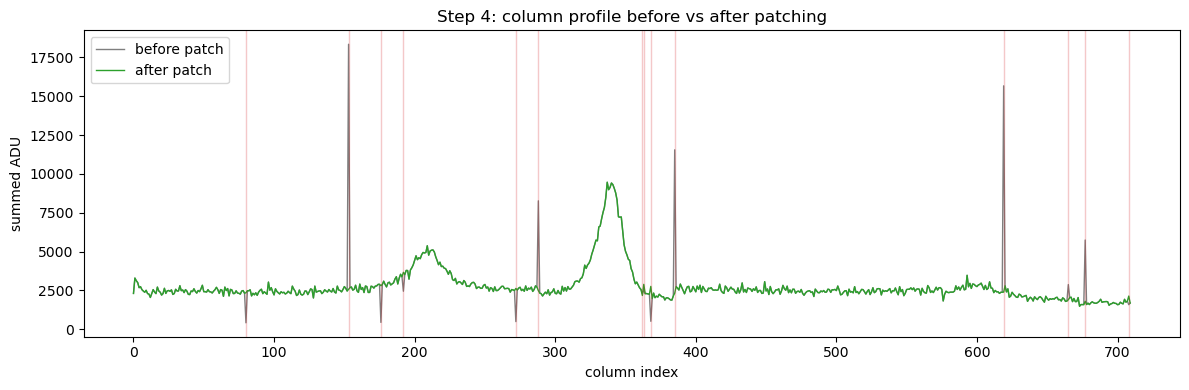

In [11]:
# Before/after on the raw column profile: spikes/dips at flagged columns
# are pulled back onto the local trend.
prof_after = np.clip(run.epix_reduced, 0, None).sum(axis=0)
prof_before = np.clip(before_patch, 0, None).sum(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(prof_before, color='tab:gray', lw=1.0, label='before patch')
ax.plot(prof_after, color='tab:green', lw=1.0, label='after patch')
for c in auto:
    ax.axvline(c, color='tab:red', alpha=0.25, lw=1)
ax.set_xlabel('column index'); ax.set_ylabel('summed ADU')
ax.set_title('Step 4: column profile before vs after patching')
ax.legend(); plt.tight_layout(); plt.show()

## Step 5 — `reduce_detector_spatial`: two row-ROIs → two 1D spectra

**YAML:**
```yaml
- step: reduce_detector_spatial
  on: epix_reduced
  rois: [[228, 248], [158, 180]]
  combine_rois: false
  reduction: sum
  axis: 0
```

Now we collapse the **cross-dispersion (row)** axis. `axis: 0` means the ROIs
select ranges of *rows*; `combine_rois: false` keeps the two bands separate.
Each ROI's rows are summed (`reduction: sum`), leaving the 710-pixel dispersion
axis intact:

- **ROI_1 = rows 228–248 → `epix_reduced_ROI_1`** = Fe **Kα** spectrum `(710,)`
- **ROI_2 = rows 158–180 → `epix_reduced_ROI_2`** = Fe **Kβ** spectrum `(710,)`

At this point we have raw 1D spectra, but the x-axis is still *pixel index*, not
energy.

Spatial reduction: epix_reduced -> epix_reduced_ROI_1
Spatial reduction: epix_reduced -> epix_reduced_ROI_2
Kα (ROI_1) spectrum shape : (710,)
Kβ (ROI_2) spectrum shape : (710,)


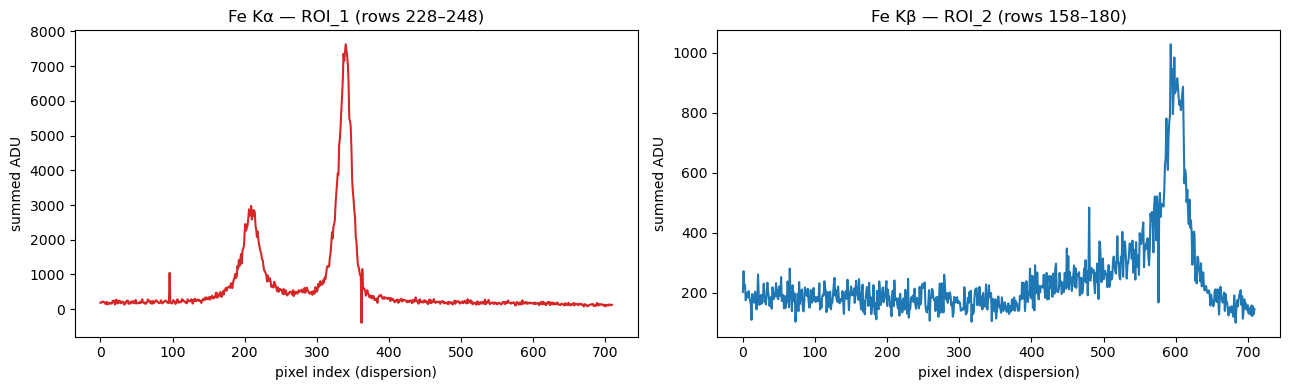

In [12]:
reduce_detector_spatial(
    run, on='epix_reduced', rois=[[228, 248], [158, 180]],
    combine_rois=False, reduction='sum', axis=0,
)

kalpha_px = run.epix_reduced_ROI_1
kbeta_px  = run.epix_reduced_ROI_2
print('Kα (ROI_1) spectrum shape :', kalpha_px.shape)
print('Kβ (ROI_2) spectrum shape :', kbeta_px.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(kalpha_px, color='tab:red'); axes[0].set_title('Fe Kα — ROI_1 (rows 228–248)')
axes[1].plot(kbeta_px, color='tab:blue'); axes[1].set_title('Fe Kβ — ROI_2 (rows 158–180)')
for ax in axes:
    ax.set_xlabel('pixel index (dispersion)'); ax.set_ylabel('summed ADU')
plt.tight_layout(); plt.show()

## Steps 6 & 7 — `make_energy_axis`: pixel index → photon energy

**YAML (Kα):**
```yaml
- step: make_energy_axis
  detector_key: epix_reduced_ROI_1
  n_pixels: 710
  crystal_detector_distance: 42.75   # A (mm) — starting estimate!
  crystal_radius: 250.0              # R (mm)
  d_spacing: 0.981                   # LiNbO3 (2 3 -4), Angstrom
  mm_per_pixel: 0.05
  name: kalpha
```
**YAML (Kβ):** same, with `epix_reduced_ROI_2`, `crystal_detector_distance:
50.6`, `d_spacing: 0.8946` (Ge 620), `name: kbeta`.

This converts pixel position to energy using the **von Hamos** dispersive
geometry. For each pixel it computes a position `ll` on the detector, the Bragg
angle `θ = arctan(R / (ll + A))`, and Bragg's law `E = hc / (2 d sinθ)`:

```
gl     = pixel_index * mm_per_pixel
ll     = gl/2 - (max(gl) - min(gl))/4
energy = 12398.42 / (2 * d * sin(arctan(R / (ll + A))))[::-1]
```

The output is stored as `run.kalpha_energy` and `run.kbeta_energy` — two
`(710,)` eV axes. These depend only on geometry, so they're the same for every
run (which is why the pipeline stores them once at the top level of the HDF5).

> ⚠️ **Calibration caveat (from the README):** `crystal_detector_distance` is a
> *starting estimate*. The Kβ axis is known to sit ~47 eV off the tabulated line
> until `A` is refined against a reference. Relative/deviation metrics are
> unaffected, but don't quote absolute energies from these defaults yet.

In [13]:
make_energy_axis(run, detector_key='epix_reduced_ROI_1', n_pixels=710,
                 crystal_detector_distance=42.75, crystal_radius=250.0,
                 d_spacing=0.981, mm_per_pixel=0.05, name='kalpha')

make_energy_axis(run, detector_key='epix_reduced_ROI_2', n_pixels=710,
                 crystal_detector_distance=50.6, crystal_radius=250.0,
                 d_spacing=0.8946, mm_per_pixel=0.05, name='kbeta')

ka_E = run.kalpha_energy
kb_E = run.kbeta_energy
print('kalpha_energy: %.1f – %.1f eV' % (ka_E.min(), ka_E.max()))
print('kbeta_energy : %.1f – %.1f eV' % (kb_E.min(), kb_E.max()))

Energy axis: kalpha_energy (710 pixels, center 6411.1 eV)
Energy axis: kbeta_energy (710 pixels, center 7070.2 eV)
kalpha_energy: 6377.1 – 6452.5 eV
kbeta_energy : 7025.5 – 7122.9 eV


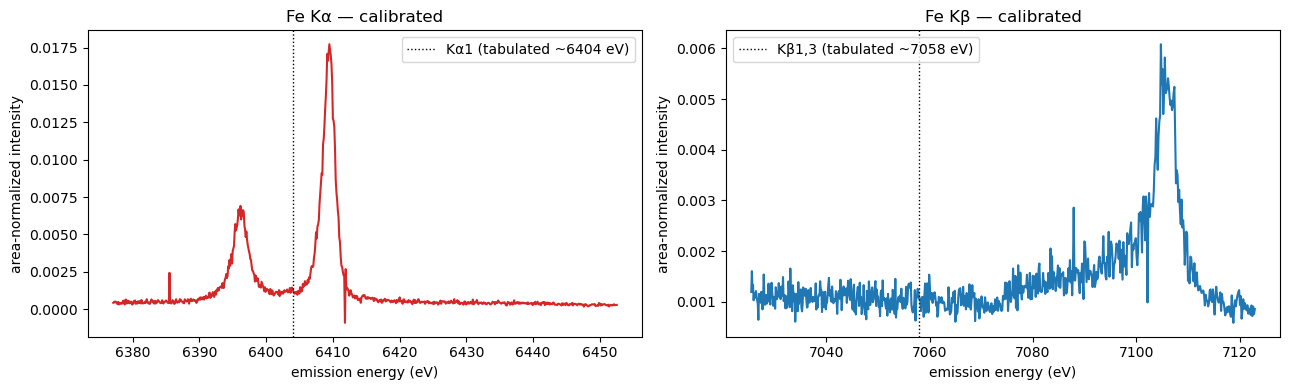

Note the Kβ offset vs the dotted tabulated line — that is the 
crystal_detector_distance calibration caveat mentioned above.


In [14]:
# Final calibrated, area-normalized spectra — the pipeline's per-run product.
def area_norm(y):
    y = np.asarray(y, float)
    s = np.nansum(y)
    return y / s if s > 0 else y

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ka_E, area_norm(kalpha_px), color='tab:red')
axes[0].axvline(6404, ls=':', color='k', lw=1, label='Kα1 (tabulated ~6404 eV)')
axes[0].set_title('Fe Kα — calibrated'); axes[0].legend()

axes[1].plot(kb_E, area_norm(kbeta_px), color='tab:blue')
axes[1].axvline(7058, ls=':', color='k', lw=1, label='Kβ1,3 (tabulated ~7058 eV)')
axes[1].set_title('Fe Kβ — calibrated'); axes[1].legend()
for ax in axes:
    ax.set_xlabel('emission energy (eV)'); ax.set_ylabel('area-normalized intensity')
plt.tight_layout(); plt.show()

print('Note the Kβ offset vs the dotted tabulated line — that is the ')
print('crystal_detector_distance calibration caveat mentioned above.')

## Recap — what each step wrote onto `run`

| Step | Function | Read | Wrote |
|------|----------|------|-------|
| 1 | `union_shots` | `epix`, `xray` | `epix` (fewer shots) |
| 2 | `filter_detector_adu` | `epix` | `epix` (noise zeroed) |
| 3 | `reduce_detector_shots` | `epix` | `epix_reduced` (2D), `epix`→None |
| 4 | `patch_pixels` | `epix_reduced` | `epix_reduced` (repaired) + diagnostics |
| 5 | `reduce_detector_spatial` | `epix_reduced` | `epix_reduced_ROI_1`, `_ROI_2` (1D) |
| 6 | `make_energy_axis` | (geometry) | `kalpha_energy` |
| 7 | `make_energy_axis` | (geometry) | `kbeta_energy` |

**The key idea:** a pipeline step is just a function that reads named attributes
off the `run` object and writes named attributes back. The YAML is only an
ordered list of `(function name, arguments)`. Running `Pipeline.from_yaml(...).
run()` does exactly what we did above — for every run in `data.runs`, in
parallel — then collects `run_<N>.kalpha` / `run_<N>.kbeta` + the shared energy
axes into `results/runs_36_54_static_xes.h5`.

### Where to go next
- **Change a knob and re-run a cell:** try `adu_threshold=0` (step 2) and watch
  the baseline balloon, or shift the ROI rows (step 5) and see the spectrum
  degrade — this builds intuition for why each value was chosen.
- **See all 19 runs together:** open
  `mfx100895324_static_xes_visualization.ipynb`, which loads the finished
  `results/*.h5` and does the redox series (IAD, linear-combination fit, %
  deviation vs the Fe(III) reference).
- **Read the source:** every step lives in `XSpect/analysis/spectroscopy.py`
  and `XSpect/analysis/xes.py`, each decorated with `@register_step("name")`.